# Mirage Score Analysis — Text-Only VC Prediction

**Research Question:** How well can an LLM predict Visual Complexity (VC) without ever seeing the image?

We test two text-only input conditions:
1. **User comment** — raw crowd-sourced comment(s) describing the visualization
2. **LLM explanation** — a prior AI-generated textual description (from the `v0_tw_dyn` model)

Each condition is run with two models: **claude-sonnet-4-6** and **gpt-5.4**.

**Mirage Score** = $\dfrac{r_{\text{text-only}}}{r_{\text{with-image}}}$

A Mirage Score near 1.0 means the LLM barely needed the image; a score near 0 means the image was essential.
Reference: the "mirage" effect was first noted when a researcher accidentally omitted images but still obtained surprisingly high correlations with human ratings.

## 1. Import Libraries and Load Environment Variables

In [1]:
import os
import json
import time
import asyncio
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import anthropic
import openai
from dotenv import load_dotenv

# ── Load API keys ────────────────────────────────────────────────────────────
ENV_PATH = Path('..') / '.env'
load_dotenv(dotenv_path=ENV_PATH)

ANTHROPIC_API_KEY = os.environ.get('ANTHROPIC_API_KEY')
OPENAI_API_KEY    = os.environ.get('OPENAI_API_KEY')

assert ANTHROPIC_API_KEY, 'ANTHROPIC_API_KEY not found in .env'
assert OPENAI_API_KEY,    'OPENAI_API_KEY not found in .env'
print('API keys loaded.')

# ── Paths ────────────────────────────────────────────────────────────────────
RESULTS_DIR   = Path('..') / 'results'
COMMENTS_CSV  = Path('..') / 'comment_process' / 'ResultsStepByStep - 4.0.imageDataCompiled.csv'
GT_CSV        = Path('gt_all_66.csv')   # human-rated ground truth (66 images)

IMG_SCORES_CSV = RESULTS_DIR / 'vc_api_63_v0_tw_dyn' / 'vc_scores.csv'
IMG_EXPL_CSV   = RESULTS_DIR / 'vc_api_63_v0_tw_dyn' / 'vc_explanations.csv'

# ── Output dirs for text-only runs (base prompt) ──────────────────────────
MIRAGE_DIRS = {
    ('comment',     'claude'): RESULTS_DIR / 'vc_api_63_mirage_comment_claude',
    ('comment',     'gpt'):    RESULTS_DIR / 'vc_api_63_mirage_comment_gpt',
    ('explanation', 'claude'): RESULTS_DIR / 'vc_api_63_mirage_explanation_claude',
    ('explanation', 'gpt'):    RESULTS_DIR / 'vc_api_63_mirage_explanation_gpt',
}
for d in MIRAGE_DIRS.values():
    d.mkdir(parents=True, exist_ok=True)

# ── Output dirs for "no image" explicit prompt condition ──────────────────
MIRAGE_DIRS_NO_IMAGE_STATED = {
    ('comment',     'claude'): RESULTS_DIR / 'vc_api_63_mirage_comment_claude_no_image_stated',
    ('comment',     'gpt'):    RESULTS_DIR / 'vc_api_63_mirage_comment_gpt_no_image_stated',
    ('explanation', 'claude'): RESULTS_DIR / 'vc_api_63_mirage_explanation_claude_no_image_stated',
    ('explanation', 'gpt'):    RESULTS_DIR / 'vc_api_63_mirage_explanation_gpt_no_image_stated',
}
for d in MIRAGE_DIRS_NO_IMAGE_STATED.values():
    d.mkdir(parents=True, exist_ok=True)

CLAUDE_MODEL = 'claude-sonnet-4-6'
GPT_MODEL    = 'gpt-5.4'

print('Paths configured.')

API keys loaded.
Paths configured.


## 2. Load Reference Data (Image-Based VC Scores)

In [2]:
# Image-based VC predictions (the reference "with-image" condition)
df_img = pd.read_csv(IMG_SCORES_CSV)
df_img.columns = ['imageName', 'vc_img']
df_img['vc_img'] = pd.to_numeric(df_img['vc_img'], errors='coerce')

# Human-rated ground truth
df_gt = pd.read_csv(GT_CSV)   # columns: imageName, NormalizedVC

# Merge
df_ref = df_img.merge(df_gt.rename(columns={'NormalizedVC': 'vc_human'}),
                      on='imageName', how='inner')

print(f'Reference set: {len(df_ref)} images')
print(df_ref.head())
df_ref.describe()

Reference set: 66 images
                       imageName  vc_img  vc_human
0                  visMost97.png    0.25      0.38
1                     wsj135.png    0.33      0.35
2  economist_daily_chart_165.png    0.45      0.43
3                   whoO06_2.png    0.58      0.45
4            SciVisJ.1025.11.png    0.45      0.36


,vc_img,vc_human
count,66.000000,66.000000
mean,0.561667,0.573939
std,0.213776,0.174672
min,0.070000,0.220000
25%,0.405000,0.435000
50%,0.580000,0.565000
75%,0.742500,0.715000
max,0.880000,0.950000


## 3. Load Input Texts (Comments and Explanations)

In [3]:
# ── User comments ─────────────────────────────────────────────────────────
df_raw_comments = pd.read_csv(COMMENTS_CSV)

# Work only with the 66 reference images to avoid noise from the full 520-row dataset
image_names = df_ref['imageName'].tolist()
df_ref_comments = df_raw_comments[df_raw_comments['imageName'].isin(image_names)]

# Aggregate comments per image; fallback to CuratePhrasesMore/LessComplex only
# when rawUserComments is entirely absent for that image.
comment_map = {}
for name, grp in df_ref_comments.groupby('imageName'):
    parts = [c for c in grp['rawUserComments'].dropna().str.strip().tolist() if c]
    if parts:
        comment_map[name] = '\n\n'.join(
            f'Comment {i+1}: {c}' for i, c in enumerate(parts)
        )
    else:
        fallback = grp['CuratePhrasesMore/LessComplex'].dropna().str.strip().tolist()
        if fallback:
            comment_map[name] = f'Description: {"; ".join(fallback)}'
            print(f'  Fallback used for {name}: {comment_map[name]}')

# ── Prior LLM explanations ─────────────────────────────────────────────────
df_expl = pd.read_csv(IMG_EXPL_CSV)
explanation_map = dict(zip(df_expl['filename'], df_expl['explanation']))

# ── Build aligned text DataFrame for the 66-image reference set ───────────
df_texts = pd.DataFrame({
    'imageName':   image_names,
    'comment':     [comment_map.get(n, '') for n in image_names],
    'explanation': [explanation_map.get(n, '') for n in image_names],
})

missing_comments     = df_texts['comment'].str.strip().eq('').sum()
missing_explanations = df_texts['explanation'].str.strip().eq('').sum()
print(f'Images: {len(df_texts)}')
print(f'Missing comments:     {missing_comments}')
print(f'Missing explanations: {missing_explanations}')
df_texts.head()

  Fallback used for SciVisJ.822.18.png: Description: Comprehensibility; Readability
Images: 66
Missing comments:     0
Missing explanations: 0


,imageName,comment,explanation
0,visMost97.png,"Comment 1: uses common knowledge, is easy to u...","This is a clean, simple infographic with a wor..."
1,wsj135.png,Comment 1: Left one is just a time scale with ...,This is a straightforward grouped bar chart wi...
2,economist_daily_chart_165.png,Comment 1: The left image is simpler than the ...,This is a straightforward horizontal stacked b...
3,whoO06_2.png,Comment 1: has a title and legend,This horizontal stacked bar chart displays 19 ...
4,SciVisJ.1025.11.png,"Comment 1: Lots of inscription with details, s...",This is a scatter plot with 16 labeled data po...


## 4. Define LLM API Call Functions (Claude & GPT)

In [4]:
SYSTEM_PROMPT_TEXT = """You are a visual complexity (VC) scoring expert for data visualizations.

**Visual Complexity** measures the amount of detail, intricacy, and perceptual/cognitive demand of a visualization image. It is scored on a 0–1 scale where 0 = minimal complexity and 1 = maximum complexity.

You will receive a text description of a visualization. Score its visual complexity based solely on the information in this text.

## Topics to Consider When Scoring

When assessing visual complexity, consider the following 7 topics that commonly drive complexity perception. You do not need to score each topic individually — use them as mental checkpoints to arrive at a holistic vc_score.

1. **Data Density / Image Clutter** — The perceived amount, richness, or depth of data content. Considers information volume, element quantity, and visual clutter/overlap.
2. **Visual Encoding Clarity** — The variety, type, and complexity of graphical forms (shapes, lines, marks) and how spatial layout, scale, and encoding interpretability contribute to complexity.
3. **Semantics / Text Legibility** — The quantity and density of text elements (titles, axis labels, legends, captions, annotations, in-chart labels).
4. **Schema** — Whether specialized domain knowledge is needed, including dimensionality (2D/3D), structural complexity, and abstraction level.
5. **Color, Symbol, and Texture Details** — Range, variety, and arrangement of colors, plus use of symbols, textures, and non-color graphical markers.
6. **Aesthetics Uncertainty** — How visually cluttered, dense, or disordered the layout appears. Higher = more cluttered/overwhelming.
7. **Immediacy / Cognitive Load** — Overall ease or difficulty of interpreting the visualization.

## Weighting of Topics for the Overall vc_score
Assign your own relative importance to each topic based on what the text reveals. Let the described characteristics guide which topics matter most for this particular case.

## Output Format
Return ONLY valid JSON (no markdown fences, no explanation outside JSON):
{
  "vc_score": <float 0-1, weighted holistic judgment>,
  "explanation": "<2-3 sentence justification referencing the topics that most influenced the score>"
}"""

# Variant: explicitly tells the model no image will be provided.
# Only the one sentence is changed; everything else is identical.
SYSTEM_PROMPT_TEXT_NO_IMAGE_STATED = SYSTEM_PROMPT_TEXT.replace(
    "Score its visual complexity based solely on the information in this text.",
    "Score its visual complexity based solely on the information in this text"
    " — you do NOT have access to the actual image."
)

# Single unified prompt — source identity (comment vs explanation) is hidden
# to avoid framing confounds. The only variable is the text content itself.
SYSTEM_PROMPTS = {
    'comment':     SYSTEM_PROMPT_TEXT,
    'explanation': SYSTEM_PROMPT_TEXT,
}


def _parse_json_response(raw: str) -> dict:
    text = raw.strip()
    if text.startswith('```'):
        text = text.split('```')[1]
        if text.startswith('json'):
            text = text[4:]
        text = text.strip()
    return json.loads(text)


async def _call_claude_async(aclient, sem, img_name: str, text_input: str,
                              system_prompt: str, max_retries: int = 3) -> float | None:
    async with sem:
        user_msg = (
            f"Score the visual complexity of this visualization based on the following text:\n\n{text_input}"
        )
        for attempt in range(max_retries):
            try:
                response = await aclient.messages.create(
                    model=CLAUDE_MODEL,
                    max_tokens=500,
                    temperature=0,
                    system=[{'type': 'text', 'text': system_prompt}],
                    messages=[{'role': 'user', 'content': user_msg}],
                )
                raw = next(b.text for b in response.content if b.type == 'text')
                return _parse_json_response(raw).get('vc_score')
            except anthropic.RateLimitError as e:
                msg = str(e)
                if 'credit' in msg.lower() or 'billing' in msg.lower():
                    print(f'  [Claude] {img_name} QUOTA EXHAUSTED — check billing at console.anthropic.com')
                    print(f'           {msg[:120]}')
                    return None  # no point retrying; credits are gone
                wait = 30 * (attempt + 1)
                print(f'  [Claude] {img_name} rate-limited, waiting {wait}s ...')
                await asyncio.sleep(wait)
            except Exception as e:
                print(f'  [Claude] {img_name} error (attempt {attempt+1}): {e}')
                await asyncio.sleep(2)
        return None


async def _call_gpt_async(aclient, sem, img_name: str, text_input: str,
                           system_prompt: str, max_retries: int = 3) -> float | None:
    async with sem:
        user_msg = (
            f"Score the visual complexity of this visualization based on the following text:\n\n{text_input}"
        )
        for attempt in range(max_retries):
            try:
                response = await aclient.chat.completions.create(
                    model=GPT_MODEL,
                    max_completion_tokens=500,
                    messages=[
                        {'role': 'system', 'content': system_prompt},
                        {'role': 'user',   'content': user_msg},
                    ],
                )
                raw = response.choices[0].message.content
                return _parse_json_response(raw).get('vc_score')
            except openai.RateLimitError as e:
                msg = str(e)
                if 'insufficient_quota' in msg or 'quota' in msg.lower():
                    print(f'  [GPT] {img_name} QUOTA EXHAUSTED — check billing at platform.openai.com')
                    print(f'        {msg[:120]}')
                    return None  # no point retrying; credits are gone
                wait = 30 * (attempt + 1)
                print(f'  [GPT] {img_name} rate-limited, waiting {wait}s ...')
                await asyncio.sleep(wait)
            except Exception as e:
                print(f'  [GPT] {img_name} error (attempt {attempt+1}): {e}')
                await asyncio.sleep(2)
        return None


async def _run_batch(model: str, text_mode: str, df_texts: pd.DataFrame,
                     out_dir: Path, concurrency: int = 5,
                     system_prompt: str | None = None) -> pd.Series:
    """
    Score all images in df_texts for (model, text_mode).
    Saves incremental results to out_dir/vc_scores.csv.
    Returns a Series indexed by imageName with float vc_score values.

    system_prompt: override the default SYSTEM_PROMPTS[text_mode] if provided.
    """
    resolved_prompt = system_prompt or SYSTEM_PROMPTS[text_mode]

    scores_csv = out_dir / 'vc_scores.csv'
    expl_csv   = out_dir / 'vc_explanations.csv'

    # Resume: only treat rows with a valid numeric score as done.
    # Rows written as empty string (failed attempts) are NOT skipped,
    # so they will be retried on the next run.
    done_scores = {}
    if scores_csv.exists():
        df_done = pd.read_csv(scores_csv)
        df_done['vc_score'] = pd.to_numeric(df_done['vc_score'], errors='coerce')
        df_done = df_done.dropna(subset=['vc_score'])
        done_scores = dict(zip(df_done['filename'], df_done['vc_score']))

    # Separate images into: already done | no text (permanent skip) | to process
    skipped, to_do = [], []
    for row in df_texts.itertuples():
        if row.imageName in done_scores:
            continue
        text = getattr(row, text_mode)
        if not text or (isinstance(text, float) and np.isnan(text)) or not str(text).strip():
            skipped.append(row.imageName)
        else:
            to_do.append((row.imageName, str(text)))

    print(f'[{model}/{text_mode}]  Total: {len(df_texts)}  Done: {len(done_scores)}  '
          f'To process: {len(to_do)}  Skipped (no text): {len(skipped)}')
    for s in skipped:
        print(f'  SKIP (no text): {s}')

    if to_do:
        sem = asyncio.Semaphore(concurrency)
        if model == 'claude':
            aclient = anthropic.AsyncAnthropic(api_key=ANTHROPIC_API_KEY)
            coros = [_call_claude_async(aclient, sem, name, text, resolved_prompt)
                     for name, text in to_do]
        else:
            aclient = openai.AsyncOpenAI(api_key=OPENAI_API_KEY)
            coros = [_call_gpt_async(aclient, sem, name, text, resolved_prompt)
                     for name, text in to_do]

        results = await asyncio.gather(*coros)

        # Persist new results
        write_header_scores = not scores_csv.exists()
        write_header_expl   = not expl_csv.exists()
        with open(scores_csv, 'a', newline='', encoding='utf-8') as sf, \
             open(expl_csv,   'a', newline='', encoding='utf-8') as ef:
            import csv as _csv
            sw = _csv.writer(sf); ew = _csv.writer(ef)
            if write_header_scores: sw.writerow(['filename', 'vc_score'])
            if write_header_expl:   ew.writerow(['filename', 'input_text'])
            for (name, text), vc in zip(to_do, results):
                sw.writerow([name, vc if vc is not None else ''])
                ew.writerow([name, text[:200]])
                if vc is not None:
                    done_scores[name] = vc
                    print(f'  {name} -> {vc:.3f}')
                else:
                    print(f'  {name} -> FAILED (API error)')

    # Return a full series aligned to df_texts (skipped images stay NaN)
    return pd.Series(
        [done_scores.get(n) for n in df_texts['imageName']],
        index=df_texts['imageName'],
        dtype=float,
    )

print('Functions defined.')

Functions defined.


## 5. Run VC Prediction Using User Comments

In [5]:
# ── Claude — comment mode ────────────────────────────────────────────────
scores_comment_claude = await _run_batch(
    model='claude', text_mode='comment',
    df_texts=df_texts,
    out_dir=MIRAGE_DIRS[('comment', 'claude')],
    concurrency=5,
)
print(f'\nDone. Valid scores: {scores_comment_claude.notna().sum()}/{len(scores_comment_claude)}')

[claude/comment]  Total: 66  Done: 66  To process: 0  Skipped (no text): 0

Done. Valid scores: 66/66


In [6]:
# ── GPT — comment mode ──────────────────────────────────────────────────
scores_comment_gpt = await _run_batch(
    model='gpt', text_mode='comment',
    df_texts=df_texts,
    out_dir=MIRAGE_DIRS[('comment', 'gpt')],
    concurrency=5,
)
print(f'\nDone. Valid scores: {scores_comment_gpt.notna().sum()}/{len(scores_comment_gpt)}')

[gpt/comment]  Total: 66  Done: 66  To process: 0  Skipped (no text): 0

Done. Valid scores: 66/66


## 6. Run VC Prediction Using Previous LLM Explanations

In [7]:
# ── Claude — explanation mode ────────────────────────────────────────────
scores_expl_claude = await _run_batch(
    model='claude', text_mode='explanation',
    df_texts=df_texts,
    out_dir=MIRAGE_DIRS[('explanation', 'claude')],
    concurrency=5,
)
print(f'\nDone. Valid scores: {scores_expl_claude.notna().sum()}/{len(scores_expl_claude)}')

[claude/explanation]  Total: 66  Done: 66  To process: 0  Skipped (no text): 0

Done. Valid scores: 66/66


In [8]:
# ── GPT — explanation mode ──────────────────────────────────────────────
scores_expl_gpt = await _run_batch(
    model='gpt', text_mode='explanation',
    df_texts=df_texts,
    out_dir=MIRAGE_DIRS[('explanation', 'gpt')],
    concurrency=5,
)
print(f'\nDone. Valid scores: {scores_expl_gpt.notna().sum()}/{len(scores_expl_gpt)}')

[gpt/explanation]  Total: 66  Done: 66  To process: 0  Skipped (no text): 0

Done. Valid scores: 66/66


## 6B. Run VC Prediction with Explicit "No Image Provided" Prompt

In [9]:
# ── GPT — explanation mode (no-image-stated prompt) ──────────────────────
scores_expl_gpt_no_image_stated = await _run_batch(
    model='gpt', text_mode='explanation',
    df_texts=df_texts,
    out_dir=MIRAGE_DIRS_NO_IMAGE_STATED[('explanation', 'gpt')],
    system_prompt=SYSTEM_PROMPT_TEXT_NO_IMAGE_STATED,
    concurrency=5,
)
print(f'\nDone. Valid scores: {scores_expl_gpt_no_image_stated.notna().sum()}/{len(scores_expl_gpt_no_image_stated)}')

[gpt/explanation]  Total: 66  Done: 0  To process: 66  Skipped (no text): 0
  visMost97.png -> 0.140
  wsj135.png -> 0.240
  economist_daily_chart_165.png -> 0.280
  whoO06_2.png -> 0.460
  SciVisJ.1025.11.png -> 0.380
  whoQ44_4.png -> 0.440
  InfoVisC.133.5(3).png -> 0.440
  wsj603.png -> 0.460
  InfoVisJ.619.17.png -> 0.740
  InfoVisJ.1558.11(3).png -> 0.290
  VisJ.1515.12.png -> 0.290
  VisJ.1499.8.png -> 0.630
  v483_n7391_8_f5.png -> 0.770
  v487_n7406_7_f3.png -> 0.870
  SciVisJ.1236.10.png -> 0.900
  SciVisJ.2926.1.png -> 0.930
  InfoVisJ.2699.12.png -> 0.880
  VisJ.1197.5(3).png -> 0.890
  InfoVisJ.2402.12(1).png -> 0.910
  SciVisJ.980.12(2).png -> 0.790
  VisC.503.6.png -> 0.140
  InfoVisC.211.18.png -> 0.140
  whoJ44.png -> 0.180
  whoQ50_2.png -> 0.280
  wsj340.png -> 0.160
  InfoVisC.73.6.png -> 0.310
  VisC.167.11.png -> 0.360
  economist_daily_chart_153.png -> 0.380
  VASTJ.2908.2.png -> 0.680
  InfoVisJ.1236.13.png -> 0.740
  InfoVisJ.1558.9.png -> 0.720
  InfoVisJ.349.

In [10]:
# ── Claude — explanation mode (no-image-stated prompt) ───────────────────
scores_expl_claude_no_image_stated = await _run_batch(
    model='claude', text_mode='explanation',
    df_texts=df_texts,
    out_dir=MIRAGE_DIRS_NO_IMAGE_STATED[('explanation', 'claude')],
    system_prompt=SYSTEM_PROMPT_TEXT_NO_IMAGE_STATED,
    concurrency=5,
)
print(f'\nDone. Valid scores: {scores_expl_claude_no_image_stated.notna().sum()}/{len(scores_expl_claude_no_image_stated)}')

[claude/explanation]  Total: 66  Done: 0  To process: 66  Skipped (no text): 0
  visMost97.png -> 0.080
  wsj135.png -> 0.250
  economist_daily_chart_165.png -> 0.280
  whoO06_2.png -> 0.580
  SciVisJ.1025.11.png -> 0.420
  whoQ44_4.png -> 0.520
  InfoVisC.133.5(3).png -> 0.420
  wsj603.png -> 0.420
  InfoVisJ.619.17.png -> 0.680
  InfoVisJ.1558.11(3).png -> 0.250
  VisJ.1515.12.png -> 0.250
  VisJ.1499.8.png -> 0.620
  v483_n7391_8_f5.png -> 0.740
  v487_n7406_7_f3.png -> 0.870
  SciVisJ.1236.10.png -> 0.880
  SciVisJ.2926.1.png -> 0.910
  InfoVisJ.2699.12.png -> 0.870
  VisJ.1197.5(3).png -> 0.820
  InfoVisJ.2402.12(1).png -> 0.910
  SciVisJ.980.12(2).png -> 0.820
  VisC.503.6.png -> 0.080
  InfoVisC.211.18.png -> 0.100
  whoJ44.png -> 0.120
  whoQ50_2.png -> 0.280
  wsj340.png -> 0.150
  InfoVisC.73.6.png -> 0.320
  VisC.167.11.png -> 0.420
  economist_daily_chart_153.png -> 0.350
  VASTJ.2908.2.png -> 0.620
  InfoVisJ.1236.13.png -> 0.780
  InfoVisJ.1558.9.png -> 0.680
  InfoVisJ.3

In [11]:
# ── GPT — comment mode (no-image-stated prompt) ──────────────────────────
scores_comment_gpt_no_image_stated = await _run_batch(
    model='gpt', text_mode='comment',
    df_texts=df_texts,
    out_dir=MIRAGE_DIRS_NO_IMAGE_STATED[('comment', 'gpt')],
    system_prompt=SYSTEM_PROMPT_TEXT_NO_IMAGE_STATED,
    concurrency=5,
)
print(f'\nDone. Valid scores: {scores_comment_gpt_no_image_stated.notna().sum()}/{len(scores_comment_gpt_no_image_stated)}')

[gpt/comment]  Total: 66  Done: 0  To process: 66  Skipped (no text): 0
  visMost97.png -> 0.150
  wsj135.png -> 0.180
  economist_daily_chart_165.png -> 0.520
  whoO06_2.png -> 0.120
  SciVisJ.1025.11.png -> 0.660
  whoQ44_4.png -> 0.670
  InfoVisC.133.5(3).png -> 0.720
  wsj603.png -> 0.670
  InfoVisJ.619.17.png -> 0.720
  InfoVisJ.1558.11(3).png -> 0.400
  VisJ.1515.12.png -> 0.840
  VisJ.1499.8.png -> 0.460
  v483_n7391_8_f5.png -> 0.840
  v487_n7406_7_f3.png -> 0.710
  SciVisJ.1236.10.png -> 0.820
  SciVisJ.2926.1.png -> 0.280
  InfoVisJ.2699.12.png -> 0.740
  VisJ.1197.5(3).png -> 0.790
  InfoVisJ.2402.12(1).png -> 0.760
  SciVisJ.980.12(2).png -> 0.080
  VisC.503.6.png -> 0.690
  InfoVisC.211.18.png -> 0.080
  whoJ44.png -> 0.180
  whoQ50_2.png -> 0.080
  wsj340.png -> 0.340
  InfoVisC.73.6.png -> 0.460
  VisC.167.11.png -> 0.180
  economist_daily_chart_153.png -> 0.180
  VASTJ.2908.2.png -> 0.480
  InfoVisJ.1236.13.png -> 0.720
  InfoVisJ.1558.9.png -> 0.700
  InfoVisJ.349.1.pn

In [12]:
# ── Claude — comment mode (no-image-stated prompt) ───────────────────────
scores_comment_claude_no_image_stated = await _run_batch(
    model='claude', text_mode='comment',
    df_texts=df_texts,
    out_dir=MIRAGE_DIRS_NO_IMAGE_STATED[('comment', 'claude')],
    system_prompt=SYSTEM_PROMPT_TEXT_NO_IMAGE_STATED,
    concurrency=5,
)
print(f'\nDone. Valid scores: {scores_comment_claude_no_image_stated.notna().sum()}/{len(scores_comment_claude_no_image_stated)}')

[claude/comment]  Total: 66  Done: 0  To process: 66  Skipped (no text): 0
  visMost97.png -> 0.100
  wsj135.png -> 0.200
  economist_daily_chart_165.png -> 0.420
  whoO06_2.png -> 0.100
  SciVisJ.1025.11.png -> 0.620
  whoQ44_4.png -> 0.620
  InfoVisC.133.5(3).png -> 0.720
  wsj603.png -> 0.620
  InfoVisJ.619.17.png -> 0.650
  InfoVisJ.1558.11(3).png -> 0.650
  VisJ.1515.12.png -> 0.780
  VisJ.1499.8.png -> 0.550
  v483_n7391_8_f5.png -> 0.720
  v487_n7406_7_f3.png -> 0.720
  SciVisJ.1236.10.png -> 0.720
  SciVisJ.2926.1.png -> 0.550
  InfoVisJ.2699.12.png -> 0.720
  VisJ.1197.5(3).png -> 0.780
  InfoVisJ.2402.12(1).png -> 0.720
  SciVisJ.980.12(2).png -> 0.200
  VisC.503.6.png -> 0.620
  InfoVisC.211.18.png -> 0.050
  whoJ44.png -> 0.100
  whoQ50_2.png -> 0.150
  wsj340.png -> 0.350
  InfoVisC.73.6.png -> 0.420
  VisC.167.11.png -> 0.150
  economist_daily_chart_153.png -> 0.200
  VASTJ.2908.2.png -> 0.620
  InfoVisJ.1236.13.png -> 0.720
  InfoVisJ.1558.9.png -> 0.620
  InfoVisJ.349.1

## 7. Aggregate and Merge Prediction Results

In [13]:
def _load_saved_scores(out_dir: Path) -> dict:
    """Load previously saved vc_scores.csv from a results folder."""
    p = out_dir / 'vc_scores.csv'
    if p.exists():
        df = pd.read_csv(p)
        return dict(zip(df['filename'], pd.to_numeric(df['vc_score'], errors='coerce')))
    return {}


# Reload from disk (in case the cells were run across sessions)
def _series_from_dir(results_dir: Path, df_texts: pd.DataFrame):
    d = _load_saved_scores(results_dir)
    return pd.Series([d.get(n) for n in df_texts['imageName']],
                     index=df_texts['imageName'], dtype=float)


# Base prompt condition
scores_comment_claude = _series_from_dir(MIRAGE_DIRS[('comment', 'claude')], df_texts)
scores_comment_gpt    = _series_from_dir(MIRAGE_DIRS[('comment', 'gpt')], df_texts)
scores_expl_claude    = _series_from_dir(MIRAGE_DIRS[('explanation', 'claude')], df_texts)
scores_expl_gpt       = _series_from_dir(MIRAGE_DIRS[('explanation', 'gpt')], df_texts)

# New prompt condition: explicit no-image statement
scores_comment_claude_no_image_stated = _series_from_dir(
    MIRAGE_DIRS_NO_IMAGE_STATED[('comment', 'claude')], df_texts
)
scores_comment_gpt_no_image_stated = _series_from_dir(
    MIRAGE_DIRS_NO_IMAGE_STATED[('comment', 'gpt')], df_texts
)
scores_expl_claude_no_image_stated = _series_from_dir(
    MIRAGE_DIRS_NO_IMAGE_STATED[('explanation', 'claude')], df_texts
)
scores_expl_gpt_no_image_stated = _series_from_dir(
    MIRAGE_DIRS_NO_IMAGE_STATED[('explanation', 'gpt')], df_texts
)

# Build merged DataFrame
df_all = df_ref.copy().set_index('imageName')
df_all['vc_comment_claude']     = scores_comment_claude
df_all['vc_comment_gpt']        = scores_comment_gpt
df_all['vc_explanation_claude'] = scores_expl_claude
df_all['vc_explanation_gpt']    = scores_expl_gpt

df_all['vc_comment_claude_no_image_stated']     = scores_comment_claude_no_image_stated
df_all['vc_comment_gpt_no_image_stated']        = scores_comment_gpt_no_image_stated
df_all['vc_explanation_claude_no_image_stated'] = scores_expl_claude_no_image_stated
df_all['vc_explanation_gpt_no_image_stated']    = scores_expl_gpt_no_image_stated

df_all = df_all.reset_index()

print(df_all.shape)
print(df_all.head())
df_all.describe()

(66, 11)
                       imageName  vc_img  vc_human  vc_comment_claude  \
0                  visMost97.png    0.25      0.38               0.10   
1                     wsj135.png    0.33      0.35               0.20   
2  economist_daily_chart_165.png    0.45      0.43               0.42   
3                   whoO06_2.png    0.58      0.45               0.10   
4            SciVisJ.1025.11.png    0.45      0.36               0.62   

   vc_comment_gpt  vc_explanation_claude  vc_explanation_gpt  \
0            0.18                   0.08                0.13   
1            0.18                   0.25                0.24   
2            0.56                   0.28                0.29   
3            0.12                   0.55                0.45   
4            0.66                   0.42                0.36   

   vc_comment_claude_no_image_stated  vc_comment_gpt_no_image_stated  \
0                               0.10                            0.15   
1                      

,vc_img,vc_human,vc_comment_claude,vc_comment_gpt,vc_explanation_claude,vc_explanation_gpt,vc_comment_claude_no_image_stated,vc_comment_gpt_no_image_stated,vc_explanation_claude_no_image_stated,vc_explanation_gpt_no_image_stated
count,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000,66.000000
mean,0.561667,0.573939,0.530000,0.513182,0.545455,0.560455,0.533636,0.514394,0.546818,0.563182
std,0.213776,0.174672,0.246177,0.263130,0.290295,0.288883,0.246687,0.265910,0.289223,0.288242
min,0.070000,0.220000,0.050000,0.030000,0.030000,0.030000,0.050000,0.060000,0.030000,0.030000
25%,0.405000,0.435000,0.275000,0.257500,0.280000,0.290000,0.275000,0.220000,0.280000,0.295000
50%,0.580000,0.565000,0.620000,0.615000,0.585000,0.550000,0.620000,0.625000,0.600000,0.555000
75%,0.742500,0.715000,0.720000,0.720000,0.820000,0.840000,0.720000,0.720000,0.820000,0.855000
max,0.880000,0.950000,0.870000,0.890000,0.920000,0.940000,0.870000,0.890000,0.920000,0.950000


## 8. Compute Correlation Metrics (Pearson's r & Spearman's Ï)

In [14]:
def compute_correlations(df: pd.DataFrame, pred_col: str, gt_col: str = 'vc_human'):
    """Return (pearson_r, pearson_p, spearman_rho, spearman_p) dropping NaNs."""
    sub = df[[pred_col, gt_col]].dropna()
    if len(sub) < 3:
        return (np.nan,) * 4
    r, p_r     = stats.pearsonr(sub[pred_col],  sub[gt_col])
    rho, p_rho = stats.spearmanr(sub[pred_col], sub[gt_col])
    return r, p_r, rho, p_rho


# Conditions: base prompt + explicit-no-image prompt variant
CONDITIONS = [
    ('With Image\n(v0_tw_dyn)',                    'vc_img'),
    ('Comment\nClaude',                            'vc_comment_claude'),
    ('Comment\nGPT',                               'vc_comment_gpt'),
    ('Explanation\nClaude',                        'vc_explanation_claude'),
    ('Explanation\nGPT',                           'vc_explanation_gpt'),
    ('Comment\nClaude\n(No-image stated)',        'vc_comment_claude_no_image_stated'),
    ('Comment\nGPT\n(No-image stated)',           'vc_comment_gpt_no_image_stated'),
    ('Explanation\nClaude\n(No-image stated)',    'vc_explanation_claude_no_image_stated'),
    ('Explanation\nGPT\n(No-image stated)',       'vc_explanation_gpt_no_image_stated'),
]

rows = []
for label, col in CONDITIONS:
    r, p_r, rho, p_rho = compute_correlations(df_all, col)
    n = df_all[[col, 'vc_human']].dropna().__len__()
    rows.append({'Condition': label, 'Column': col,
                 'Pearson_r': r, 'Pearson_p': p_r,
                 'Spearman_rho': rho, 'Spearman_p': p_rho,
                 'N': n})

df_metrics = pd.DataFrame(rows)
print(df_metrics[['Condition', 'Pearson_r', 'Spearman_rho', 'N']].to_string(index=False))

                             Condition  Pearson_r  Spearman_rho  N
               With Image\n(v0_tw_dyn)   0.884480      0.889823 66
                       Comment\nClaude   0.600604      0.635114 66
                          Comment\nGPT   0.569531      0.603253 66
                   Explanation\nClaude   0.871495      0.874598 66
                      Explanation\nGPT   0.878986      0.892807 66
    Comment\nClaude\n(No-image stated)   0.603203      0.624795 66
       Comment\nGPT\n(No-image stated)   0.558603      0.590952 66
Explanation\nClaude\n(No-image stated)   0.871026      0.874848 66
   Explanation\nGPT\n(No-image stated)   0.879166      0.890475 66


## 9. Calculate Mirage Score

$$\text{Mirage Score} = \frac{r_{\text{text-only}}}{r_{\text{with-image}}}$$

A score of 1.0 means text-only matches image-based performance exactly; >1.0 means text-only is *better* (unlikely but theoretically possible).

In [19]:

# Reference (image-based) metrics
ref_r   = df_metrics.loc[df_metrics['Column'] == 'vc_img', 'Pearson_r'].values[0]
ref_rho = df_metrics.loc[df_metrics['Column'] == 'vc_img', 'Spearman_rho'].values[0]

# Text-only conditions only
text_conditions = [c for c in CONDITIONS if c[1] != 'vc_img']

mirage_rows = []
for label, col in text_conditions:
    row = df_metrics[df_metrics['Column'] == col].iloc[0]
    mirage_r   = row['Pearson_r']   / ref_r   if ref_r   != 0 else np.nan
    mirage_rho = row['Spearman_rho'] / ref_rho if ref_rho != 0 else np.nan
    mirage_rows.append({
        'Condition':    label.replace('\n', ' '),
        'Column':       col,
        'Pearson_r':    round(row['Pearson_r'],   3),
        'Spearman_rho': round(row['Spearman_rho'], 3),
        'Mirage_r':     round(mirage_r,   3),
        'Mirage_rho':   round(mirage_rho, 3),
        'N': row['N'],
    })

df_mirage = pd.DataFrame(mirage_rows)
print(f'Reference (with image):  Pearson r = {ref_r:.3f},  Spearman rho = {ref_rho:.3f}\n')
print(df_mirage.to_string(index=False))


Reference (with image):  Pearson r = 0.884,  Spearman rho = 0.890

                           Condition                                Column  Pearson_r  Spearman_rho  Mirage_r  Mirage_rho  N
                      Comment Claude                     vc_comment_claude      0.601         0.635     0.679       0.714 66
                         Comment GPT                        vc_comment_gpt      0.570         0.603     0.644       0.678 66
                  Explanation Claude                 vc_explanation_claude      0.871         0.875     0.985       0.983 66
                     Explanation GPT                    vc_explanation_gpt      0.879         0.893     0.994       1.003 66
    Comment Claude (No-image stated)     vc_comment_claude_no_image_stated      0.603         0.625     0.682       0.702 66
       Comment GPT (No-image stated)        vc_comment_gpt_no_image_stated      0.559         0.591     0.632       0.664 66
Explanation Claude (No-image stated) vc_explanation_claude

## 10. Visualize Results

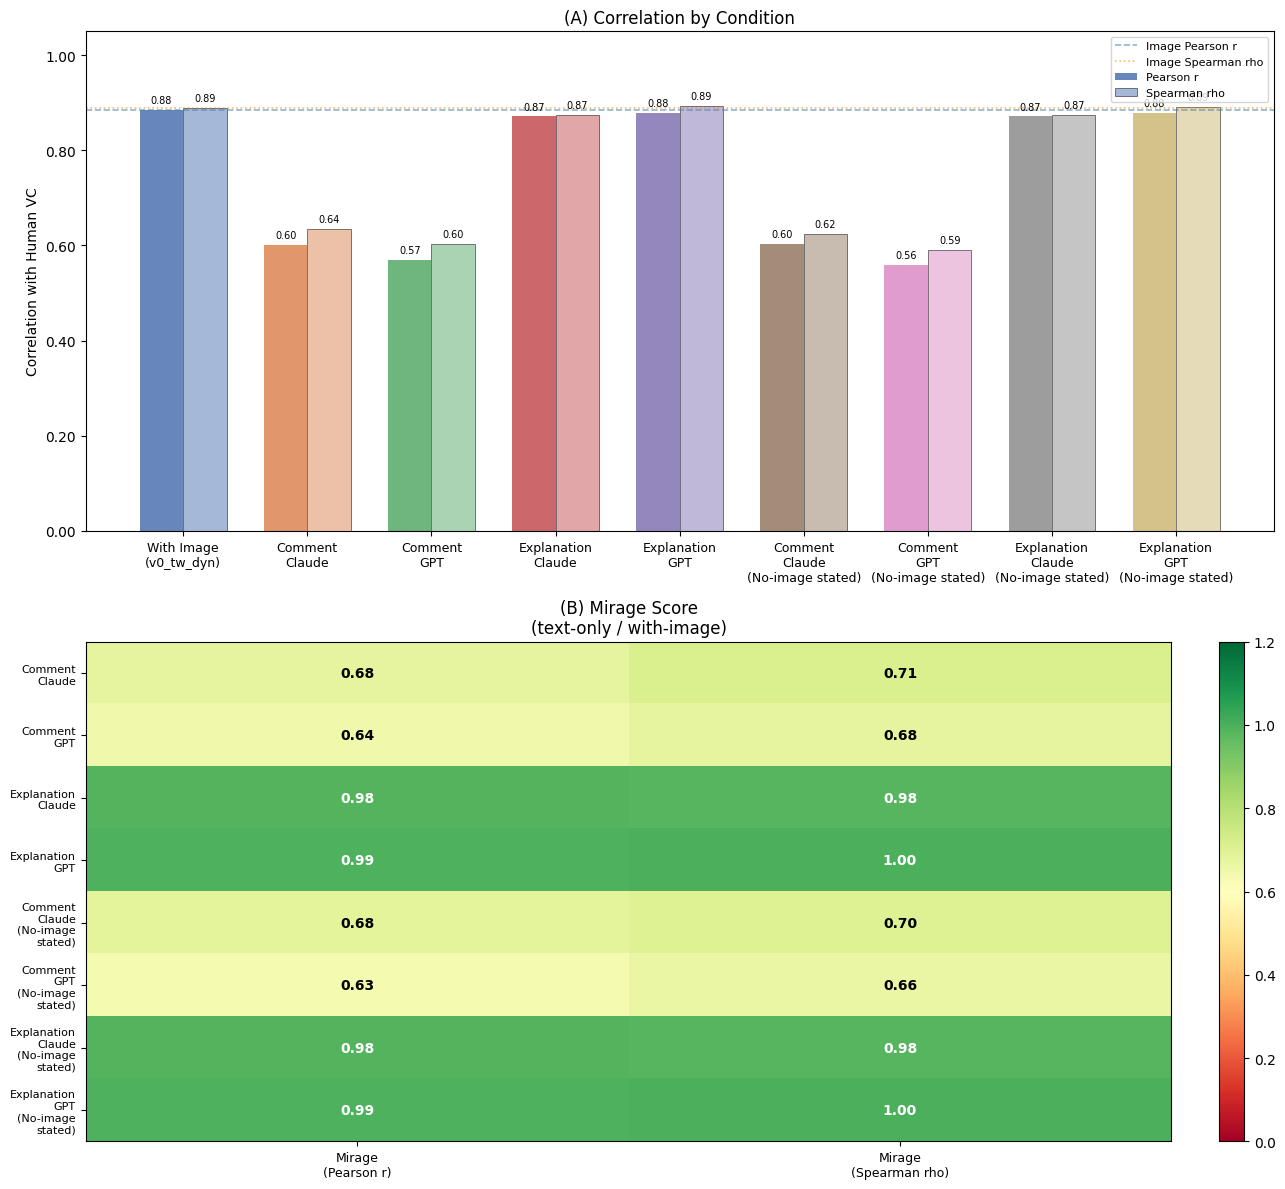

Figure saved.


In [20]:

fig, axes = plt.subplots(2, 1, figsize=(13, 12))
palette = ['#4C72B0', '#DD8452', '#55A868', '#C44E52', '#8172B2',
           '#937860', '#DA8BC3', '#8C8C8C', '#CCB974']

# ── Panel A: Correlation bar chart ──────────────────────────────────────────
all_labels = [c[0] for c in CONDITIONS]
r_values   = df_metrics['Pearson_r'].values
rho_values = df_metrics['Spearman_rho'].values

x = np.arange(len(all_labels))
width = 0.35
ax = axes[0]
bars_r   = ax.bar(x - width/2, r_values,   width, label='Pearson r',    color=palette[:len(x)], alpha=0.85)
bars_rho = ax.bar(x + width/2, rho_values, width, label='Spearman rho', color=palette[:len(x)], alpha=0.50, edgecolor='black', linewidth=0.7)

ax.axhline(ref_r,   color='steelblue',  linestyle='--', linewidth=1.2, alpha=0.6, label='Image Pearson r')
ax.axhline(ref_rho, color='darkorange', linestyle=':',  linewidth=1.2, alpha=0.6, label='Image Spearman rho')
ax.set_xticks(x)
ax.set_xticklabels(all_labels, fontsize=9)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Correlation with Human VC')
ax.set_title('(A) Correlation by Condition')
ax.legend(fontsize=8)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))

for bar in bars_r:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
for bar in bars_rho:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

# ── Panel B: Mirage Score heatmap ───────────────────────────────────────────
ax2 = axes[1]
heat_data = df_mirage[['Mirage_r', 'Mirage_rho']].values
heat_labels_row = [c.replace(' ', '\n') for c in df_mirage['Condition']]
heat_labels_col = ['Mirage\n(Pearson r)', 'Mirage\n(Spearman rho)']

im = ax2.imshow(heat_data, aspect='auto', cmap='RdYlGn', vmin=0, vmax=1.2)
ax2.set_xticks([0, 1]); ax2.set_xticklabels(heat_labels_col, fontsize=9)
ax2.set_yticks(range(len(heat_labels_row))); ax2.set_yticklabels(heat_labels_row, fontsize=8)
ax2.set_title('(B) Mirage Score\n(text-only / with-image)')
plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

for i in range(heat_data.shape[0]):
    for j in range(heat_data.shape[1]):
        v = heat_data[i, j]
        ax2.text(j, i, f'{v:.2f}', ha='center', va='center',
                 fontsize=10, fontweight='bold',
                 color='black' if 0.3 < v < 0.9 else 'white')

plt.tight_layout()
plt.savefig(Path('..') / 'figures' / 'mirage_score_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved.')


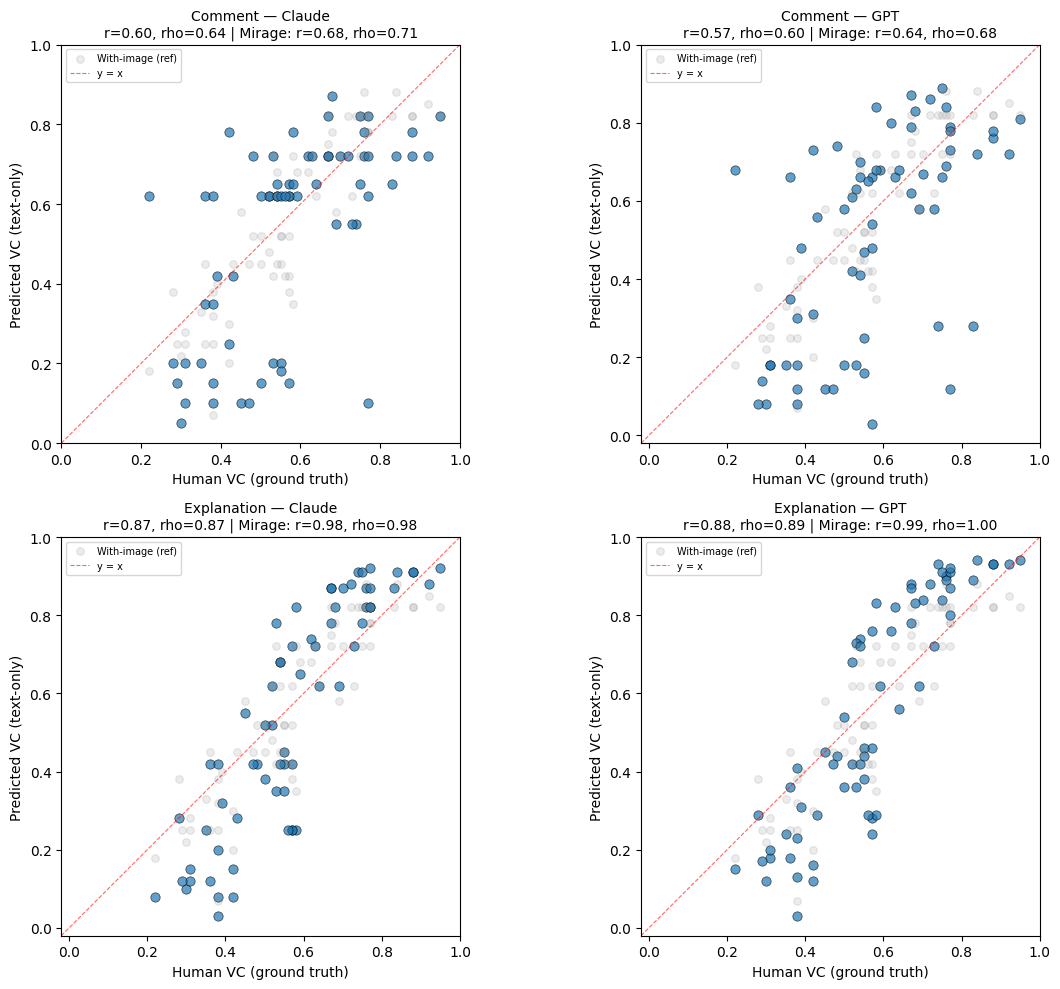

In [21]:

# ── Scatter plots: text-only predicted VC vs human VC ──────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

scatter_conditions = [
    ('Comment — Claude',      'vc_comment_claude'),
    ('Comment — GPT',         'vc_comment_gpt'),
    ('Explanation — Claude',  'vc_explanation_claude'),
    ('Explanation — GPT',     'vc_explanation_gpt'),
]

for ax, (title, col) in zip(axes, scatter_conditions):
    sub = df_all[['vc_human', col]].dropna()
    if sub.empty:
        ax.set_title(f'{title}\n(no data)')
        continue
    r, _   = stats.pearsonr(sub[col], sub['vc_human'])
    rho, _ = stats.spearmanr(sub[col], sub['vc_human'])
    row_m  = df_mirage[df_mirage['Column'] == col]
    ms_r   = row_m['Mirage_r'].values[0]   if not row_m.empty else np.nan
    ms_rho = row_m['Mirage_rho'].values[0] if not row_m.empty else np.nan

    ax.scatter(sub['vc_human'], sub[col], alpha=0.7, edgecolors='k', linewidths=0.5, s=45)
    # Reference line (image-based predictions vs human, for visual comparison)
    sub_img = df_all[['vc_human', 'vc_img']].dropna()
    ax.scatter(sub_img['vc_human'], sub_img['vc_img'],
               alpha=0.15, color='grey', s=30, label='With-image (ref)')

    lo, hi = min(sub['vc_human'].min(), sub[col].min()) - 0.05, \
             max(sub['vc_human'].max(), sub[col].max()) + 0.05
    ax.plot([lo, hi], [lo, hi], 'r--', linewidth=0.8, alpha=0.6, label='y = x')
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Human VC (ground truth)')
    ax.set_ylabel('Predicted VC (text-only)')
    ax.set_title(
        f'{title}\nr={r:.2f}, rho={rho:.2f} | Mirage: r={ms_r:.2f}, rho={ms_rho:.2f}',
        fontsize=10
    )
    ax.legend(fontsize=7)
    ax.set_aspect('equal')

plt.tight_layout()
plt.savefig(Path('..') / 'figures' / 'mirage_scatter_plots.png', dpi=150, bbox_inches='tight')
plt.show()


In [22]:

# ── Summary table ────────────────────────────────────────────────────────────
print("=" * 70)
print(f"Reference (with image)  Pearson r={ref_r:.3f}  Spearman rho={ref_rho:.3f}")
print("=" * 70)
print(df_mirage.to_string(index=False))
print("=" * 70)
print()
print("Mirage Score interpretation:")
print("  1.0  = text-only matches image performance exactly")
print("  >1.0 = text-only EXCEEDS image performance (mirage effect)")
print("  <0.5 = image was essential for good performance")


Reference (with image)  Pearson r=0.884  Spearman rho=0.890
                           Condition                                Column  Pearson_r  Spearman_rho  Mirage_r  Mirage_rho  N
                      Comment Claude                     vc_comment_claude      0.601         0.635     0.679       0.714 66
                         Comment GPT                        vc_comment_gpt      0.570         0.603     0.644       0.678 66
                  Explanation Claude                 vc_explanation_claude      0.871         0.875     0.985       0.983 66
                     Explanation GPT                    vc_explanation_gpt      0.879         0.893     0.994       1.003 66
    Comment Claude (No-image stated)     vc_comment_claude_no_image_stated      0.603         0.625     0.682       0.702 66
       Comment GPT (No-image stated)        vc_comment_gpt_no_image_stated      0.559         0.591     0.632       0.664 66
Explanation Claude (No-image stated) vc_explanation_claude_no_ima